In [1]:
# Notebook d'exploration des données pour la création de features et le choix d'un modèle adapté
#
# Analyse graphique des puissances moyennes à différentes fréquences temporelles :
# - Forte saisonnalité : Puissance consommée haute en hiver qui baisse en été
# - Cycle hebdomadaire marqué : 5 jours de consommation élevée, 2 jours plus faibles (week-end)
# - Consommation plus faible la nuit
# - Courbes mensuelles très similaires d'une année sur l'autre
#
# Ces observations servent de base pour la création de features adaptées au modèle, calculées dans features_engineering.py.
#
# Compte tenu du temps imparti pour le homework, j'ai choisi un modèle XGBoost, rapide à entraîner et performant sur un historique relativement limité (27 mois). 
# Le modèle est entraîné sur les données jusqu'au 2025-06-01, le test set comprenant les 4 mois suivants. 
# L'analyse exploratoire a permis d'identifier des features pertinentes, telles que week-end, nuit/jour et périodes de vacances été/hiver, qui seront utilisées par le modèle.

#


In [2]:
import pandas as pd
from src.forecast.utils.data_processing import format_rte_files, concatenate_and_format_rte_files
from src.forecast.utils.features_engineering import add_temporal_features,compute_mean_freq_dynamic
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# chargement des données de puissance

data_power=concatenate_and_format_rte_files("/home/tiphainell/Documents/3.Energy_RTE/data_processed")#
data_power[data_power["Consommation"].isna()]



,Heure,Previsions J-1,Previsions J,Consommation,Date,timestamp


In [4]:
#Ajout de features à partir du time stamp ( year, month ...)
data_power=add_temporal_features(data_power,"timestamp","Consommation")

In [5]:
data_power

,Heure,Previsions J-1,Previsions J,Consommation,Date,timestamp,year,month,day,hour,...,Consommation_rollmean_4,Consommation_rollmean_96,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos,minute_sin,minute_cos,dow_sin,dow_cos
0,00:00,67000,66800,66814.0,01/01/2021,2021-01-01 00:00:00,2021,1,1,0,...,NaN,NaN,0.000000,1.000000,0.017213,0.999852,0.000000e+00,1.000000e+00,-0.433884,-0.900969
1,00:15,66500,66300,67092.0,01/01/2021,2021-01-01 00:15:00,2021,1,1,0,...,NaN,NaN,0.000000,1.000000,0.017213,0.999852,1.000000e+00,2.832769e-16,-0.433884,-0.900969
2,00:30,66000,65800,65773.0,01/01/2021,2021-01-01 00:30:00,2021,1,1,0,...,NaN,NaN,0.000000,1.000000,0.017213,0.999852,5.665539e-16,-1.000000e+00,-0.433884,-0.900969
3,00:45,65150,64900,64624.0,01/01/2021,2021-01-01 00:45:00,2021,1,1,0,...,NaN,NaN,0.000000,1.000000,0.017213,0.999852,-1.000000e+00,-1.836970e-16,-0.433884,-0.900969
4,01:00,64300,64000,64249.0,01/01/2021,2021-01-01 01:00:00,2021,1,1,1,...,66075.75,NaN,0.258819,0.965926,0.017213,0.999852,0.000000e+00,1.000000e+00,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105115,22:45,51900,53700,53914.0,31/12/2023,2023-12-31 22:45:00,2023,12,31,22,...,51596.00,50165.947917,-0.500000,0.866025,0.508671,0.860961,-1.000000e+00,-1.836970e-16,-0.781831,0.623490
105116,23:00,53000,54800,53964.0,31/12/2023,2023-12-31 23:00:00,2023,12,31,23,...,52228.00,50180.135417,-0.258819,0.965926,0.508671,0.860961,0.000000e+00,1.000000e+00,-0.781831,0.623490
105117,23:15,53000,54800,54240.0,31/12/2023,2023-12-31 23:15:00,2023,12,31,23,...,52965.25,50195.541667,-0.258819,0.965926,0.508671,0.860961,1.000000e+00,2.832769e-16,-0.781831,0.623490
105118,23:30,53500,55300,53642.0,31/12/2023,2023-12-31 23:30:00,2023,12,31,23,...,53528.50,50213.250000,-0.258819,0.965926,0.508671,0.860961,5.665539e-16,-1.000000e+00,-0.781831,0.623490


In [6]:
#Calcul de la puissance moyenne à differentes frequences (mensuelle, hebdomadaire, journalière ...) pur observer les tendances
# 
data_power=compute_mean_freq_dynamic(data_power,column_consommation="Consommation")


Consommation_year_avg
Consommation_month_avg
Consommation_day_avg
Consommation_hour_avg
Consommation_minute_avg
Consommation_week_avg


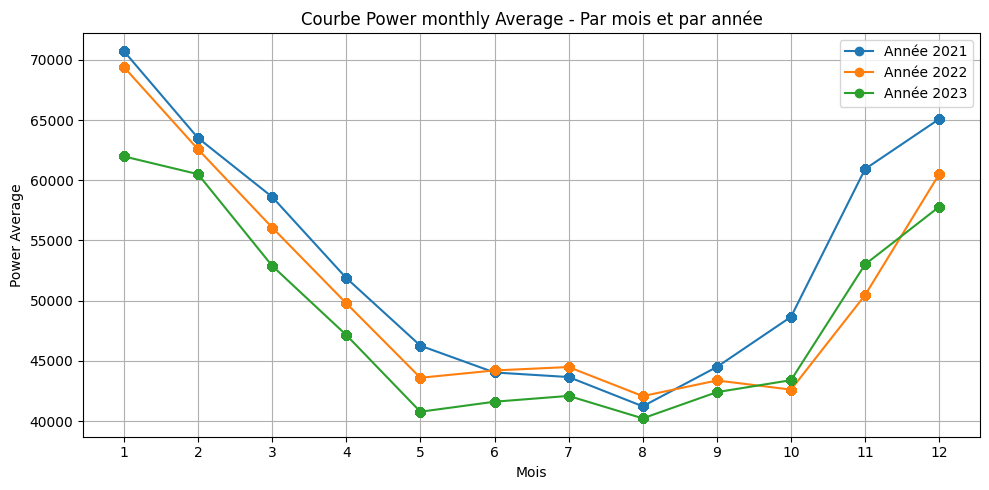

In [7]:
# Graphique de la puissance mensuelle sur les données
# 
plt.figure(figsize=(10, 5))

# Boucle sur chaque année
for year in sorted(data_power["year"].unique()):
    df_year = data_power[data_power["year"] == year].sort_values("month")
    
    plt.plot(
        df_year["month"],
        df_year["Consommation_month_avg"],
        marker='o',
        linestyle='-',
        label=f"Année {year}"
    )

plt.title("Courbe Power monthly Average - Par mois et par année")
plt.xlabel("Mois")
plt.ylabel("Power Average")
plt.grid(True)
plt.xticks(range(1, 13))  # mois 1 à 12
plt.legend()
plt.tight_layout()
plt.show()


La puissance consommée est saisonnière : forte consommation en hiver avec une baisse en été

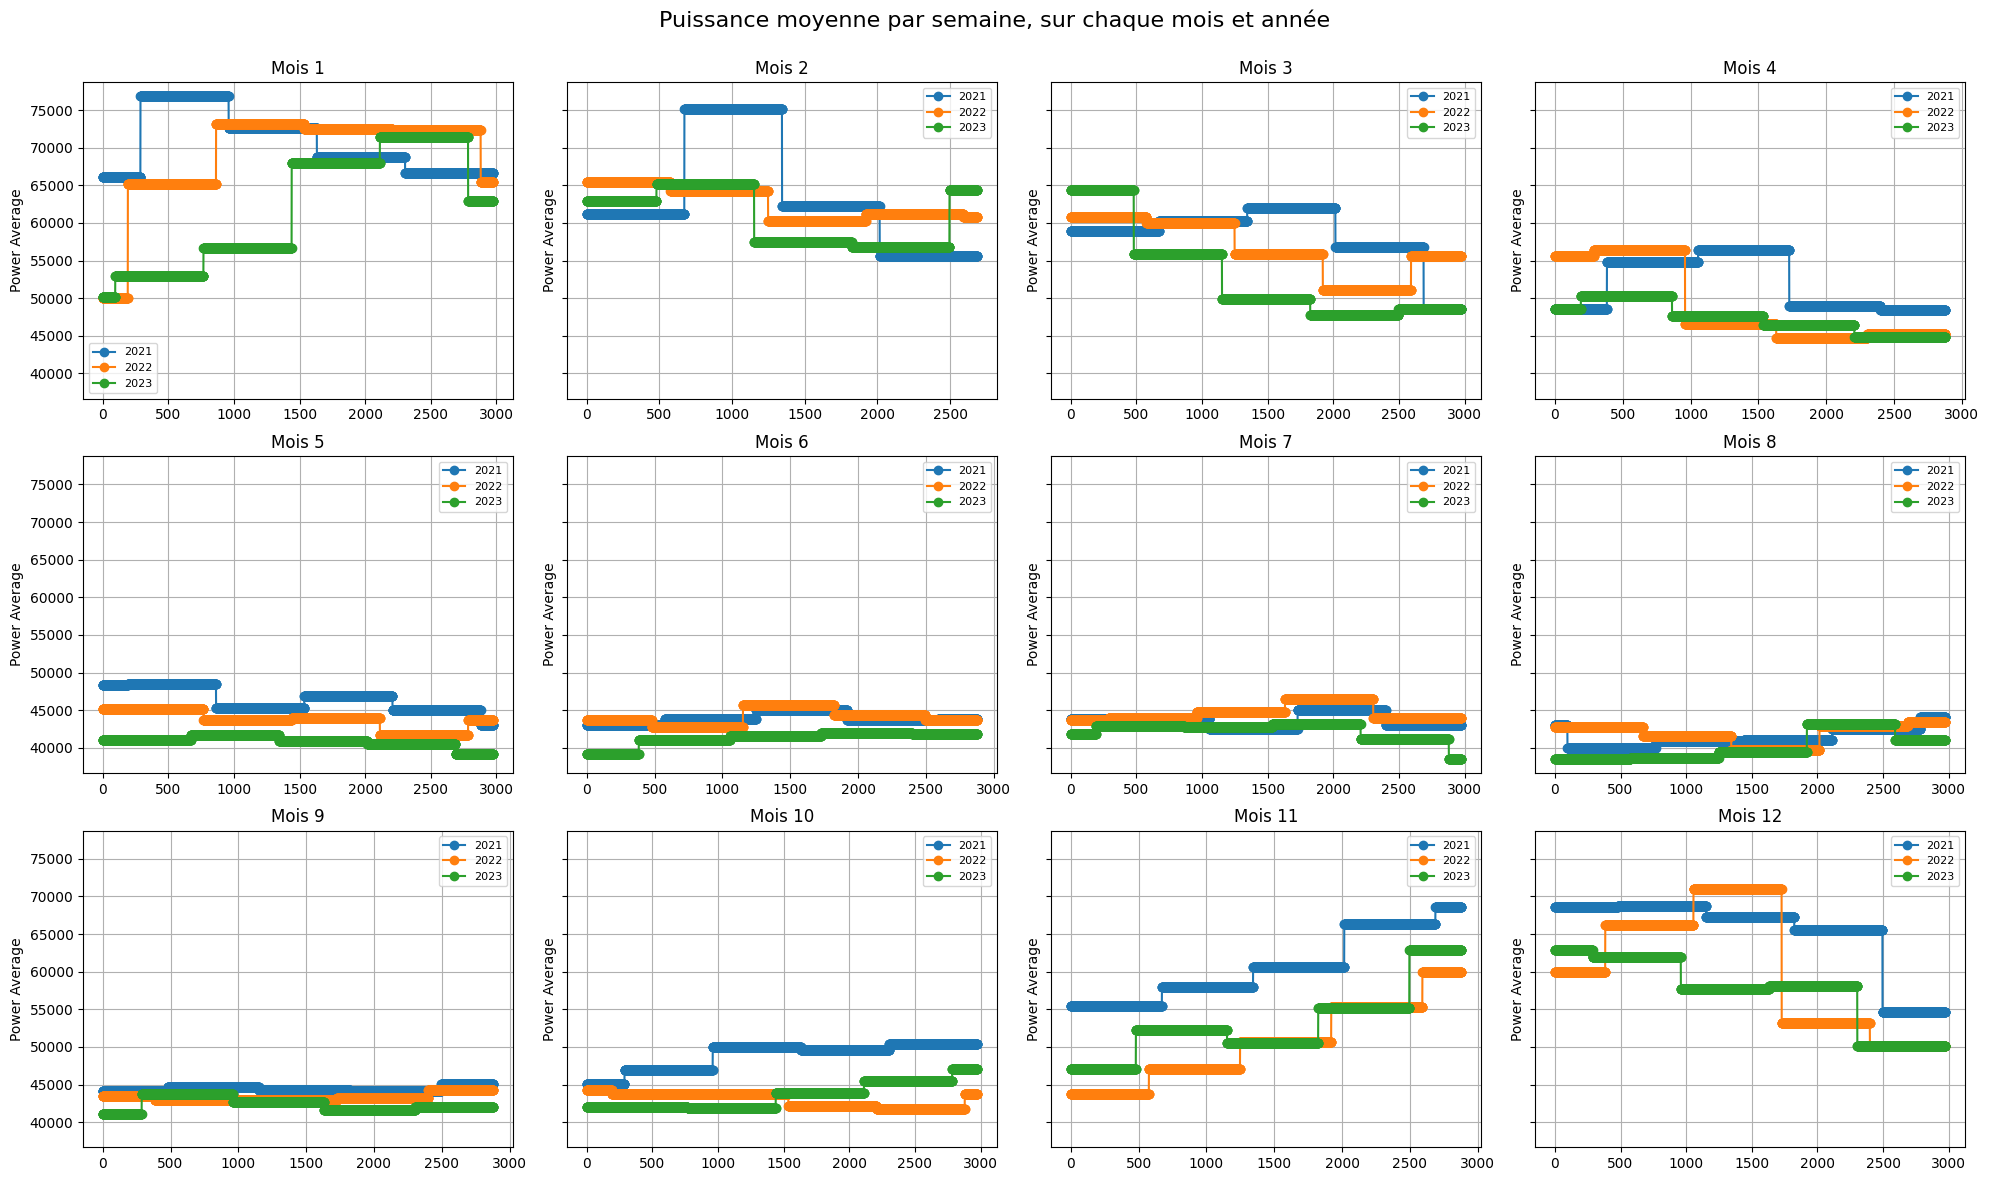

In [8]:
# Analyse de la puissance moyenne par semaine sur chaque mois
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)  # 3 lignes, 4 colonnes

for month in range(1, 13):
    ax = axes[(month-1)//4, (month-1)%4]  # Sélection du subplot
    
    # Filtrer pour le mois courant
    df_month = data_power[data_power["month"] == month]
    
    # Boucle sur chaque année
    for year in sorted(df_month["year"].unique()):
        df_year = df_month[df_month["year"] == year].reset_index(drop=True)
        
        ax.plot(
            df_year["Consommation_week_avg"],
            marker='o',
            linestyle='-',
            label=f"{year}"
        )
    
    ax.set_title(f"Mois {month}")
    ax.set_ylabel("Power Average")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.suptitle("Puissance moyenne par semaine, sur chaque mois et année", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()


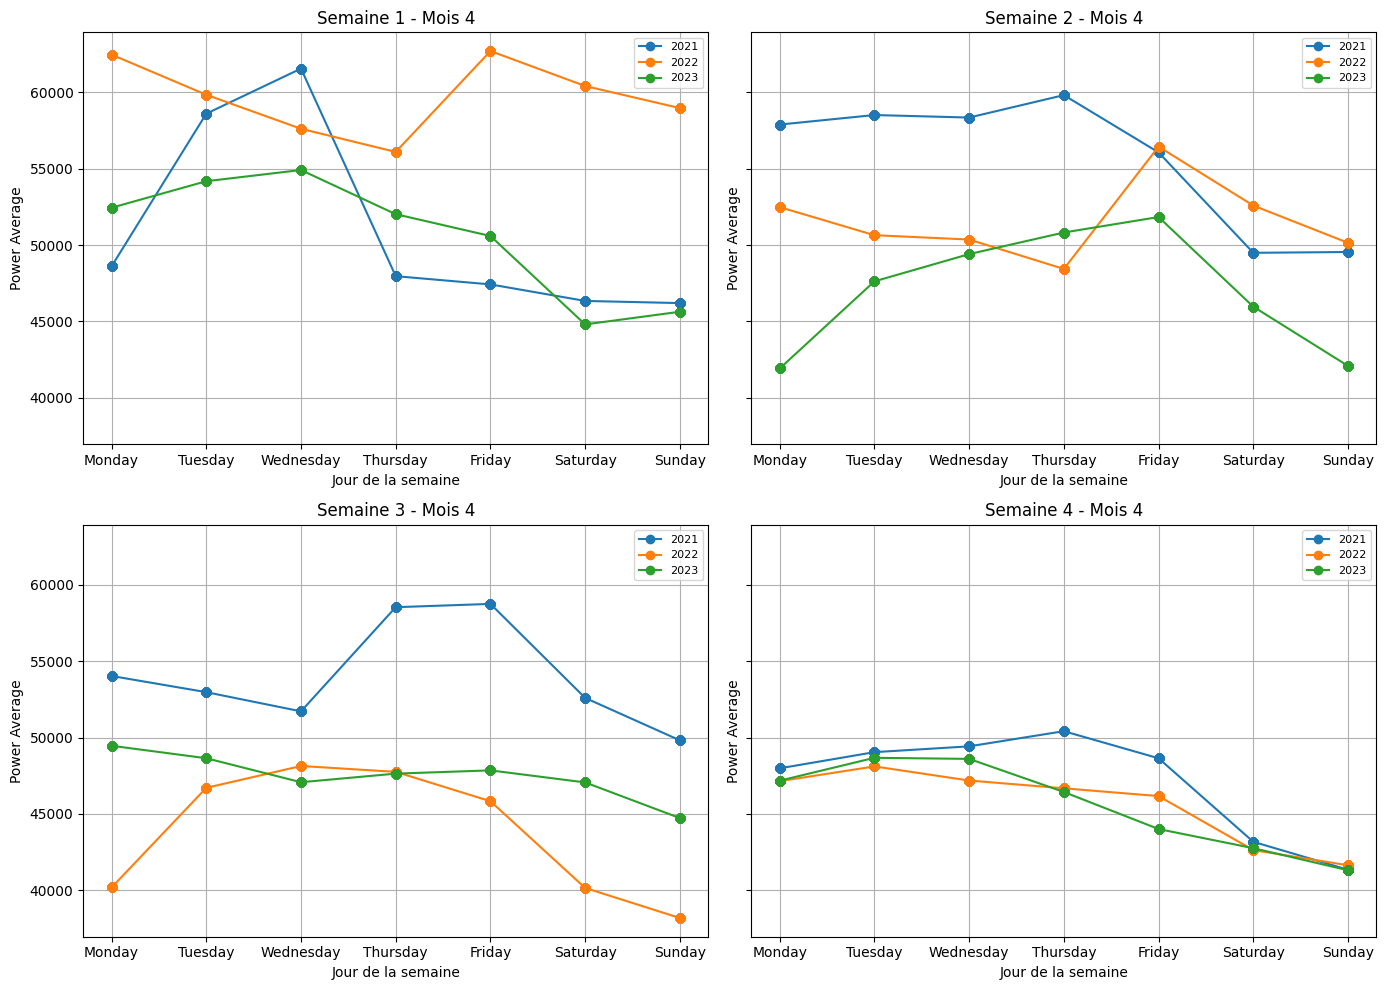

In [9]:
#Puissance moyenne par jour sur les semaines d'un mois donné
selected_month=4
    
df_month=data_power[data_power["month"] == selected_month].copy()
df_month["week_in_month"] = ((df_month["timestamp"].dt.day - 1) // 7 + 1)

# Ordre des jours pour l'axe x
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Créer la figure avec 4 sous-graphes (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for week_num in range(1, 5):
    ax = axes[(week_num-1)//2, (week_num-1)%2]
    df_week = df_month[df_month["week_in_month"] == week_num]

    for year in sorted(df_week["year"].unique()):
        df_year = df_week[df_week["year"] == year].copy()

        # Ordonner selon day_name
        df_year["day_name"] = pd.Categorical(df_year["day_name"], categories=day_order, ordered=True)
        df_year = df_year.sort_values("day_name")

        ax.plot(
            df_year["day_name"],
            df_year["Consommation_day_avg"],
            marker='o',
            linestyle='-',
            label=f"{year}"
        )

    ax.set_title(f"Semaine {week_num} - Mois {selected_month}")
    ax.set_xlabel("Jour de la semaine")
    ax.set_ylabel("Power Average")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

La puissance consommée baisse les weeks-ends -> features indiquant les week-ends

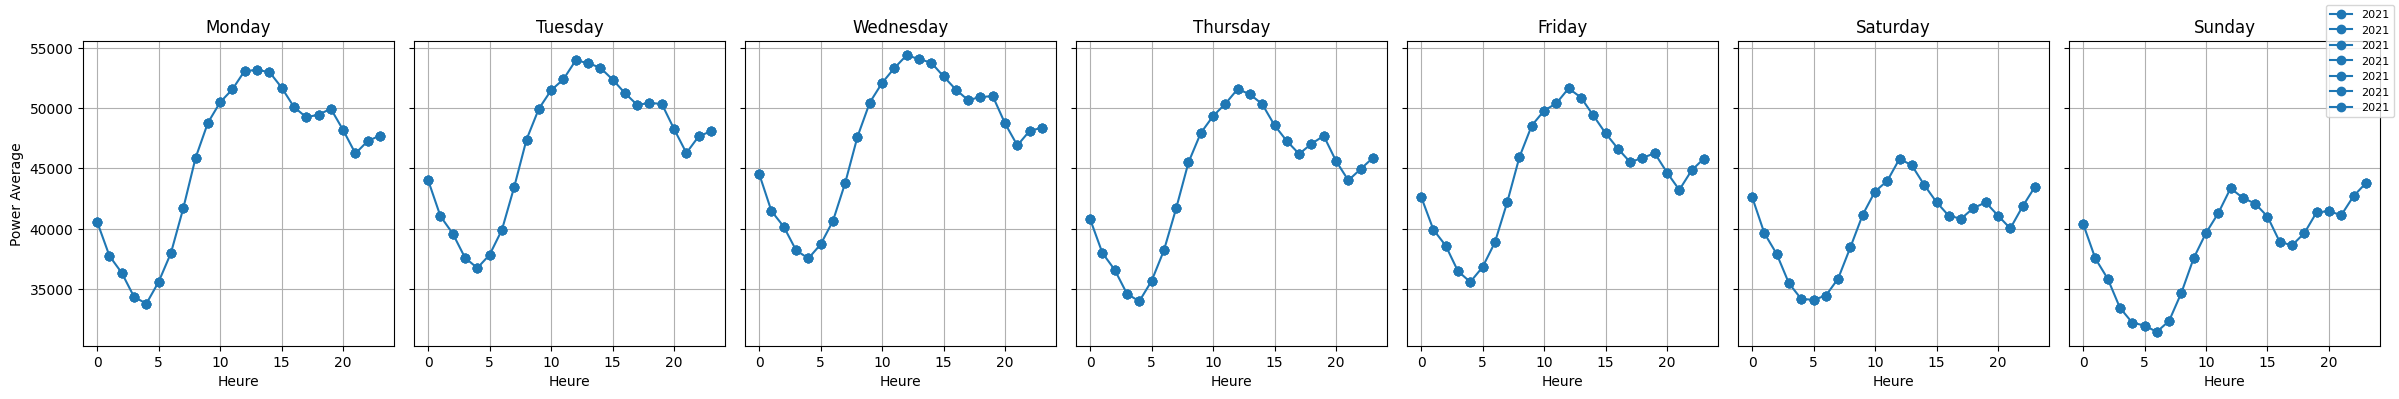

In [10]:
#Puissance moyenne par heure sur une semaine

# Assure que start_date est datetime
df = data_power.copy()
#df["start_date"] = pd.to_datetime(df["start_date"])

# Choisir la semaine à visualiser (ex: semaine 2 d'un mois donné)
selected_year = 2021
selected_month = 7
selected_week = 3

# Filtrer les données
df_week = df[
    (df["year"] == selected_year) &
    (df["month"] == selected_month)
].copy()

# Ajouter colonnes nécessaires
df_week["day_name"] = df_week["timestamp"].dt.day_name()
df_week["week_in_month"] = ((df_week["timestamp"].dt.day - 1) // 7 + 1)
df_week["hour"] = df_week["timestamp"].dt.hour

# Filtrer la semaine choisie
df_week = df_week[df_week["week_in_month"] == selected_week]

# Ordre des jours
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Créer la figure avec 7 sous-graphes (1 par jour)
fig, axes = plt.subplots(1, 7, figsize=(24, 4), sharey=True)

for i, day in enumerate(day_order):
    ax = axes[i]
    df_day = df_week[df_week["day_name"] == day]
    
    if df_day.empty:
        continue  # Pas de données pour ce jour
    
    for year in sorted(df_day["year"].unique()):
        df_year_day = df_day[df_day["year"] == year].sort_values("hour")
        
        ax.plot(
            df_year_day["hour"],
            df_year_day["Consommation_hour_avg"],
            marker='o',
            linestyle='-',
            label=f"{year}"
        )
    
    ax.set_title(day)
    ax.set_xlabel("Heure")
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("Power Average")

# Légende commune
fig.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


La puissance est sinusoidale sur une semaine avec des baisses la nuit et des pics autour de 12h.

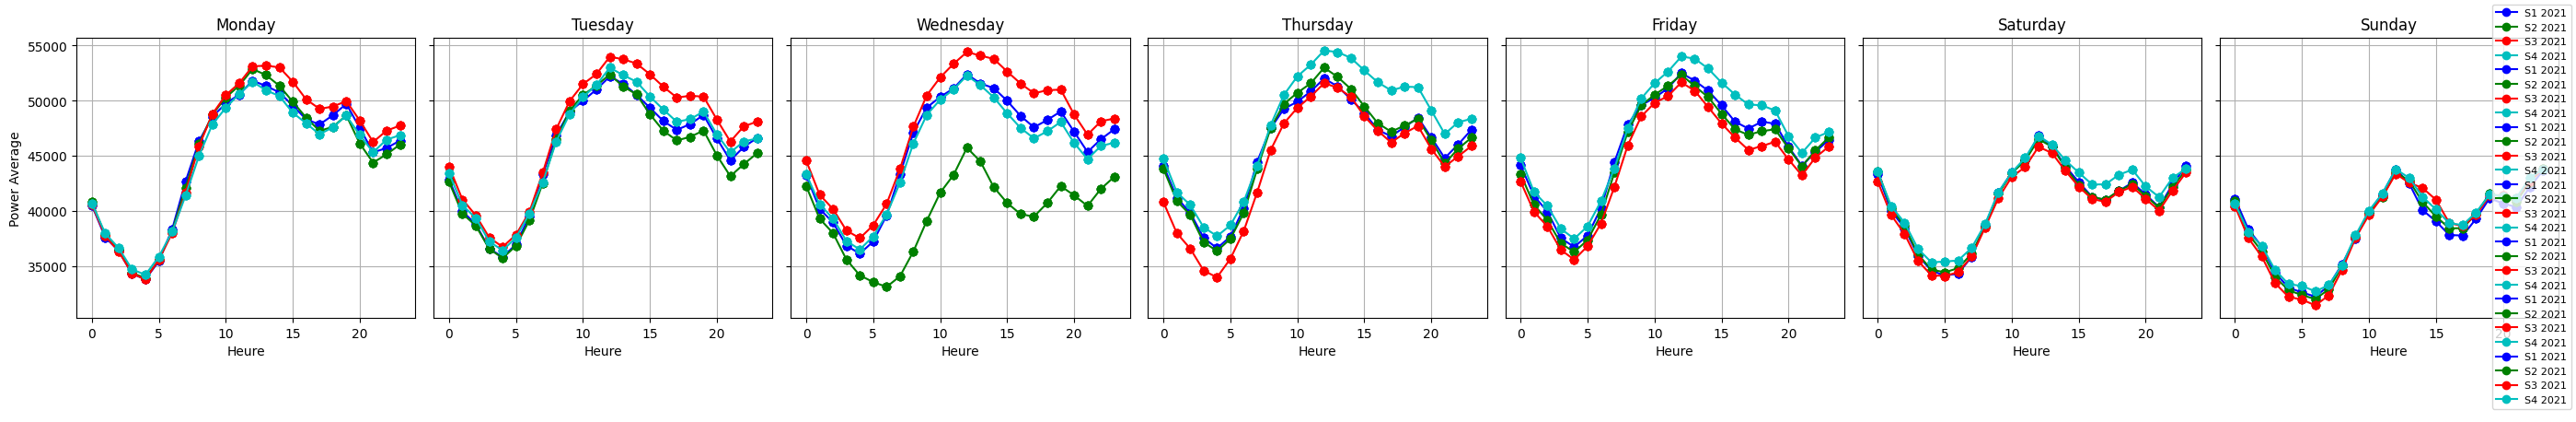

In [11]:
#Puissance moyenne par heure sur une semaine

# Assure que start_date est datetime
df = data_power.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Choisir le mois à visualiser
selected_year = 2021
selected_month = 7

# Filtrer les données
df_month = df[
    (df["year"] == selected_year) &
    (df["month"] == selected_month)
].copy()

# Ajouter colonnes nécessaires
df_month["day_name"] = df_month["timestamp"].dt.day_name()
df_month["week_in_month"] = ((df_month["timestamp"].dt.day - 1) // 7 + 1)
df_month["hour"] = df_month["timestamp"].dt.hour

# Ordre des jours pour les sous-graphes
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Créer la figure avec 7 sous-graphes (1 par jour)
fig, axes = plt.subplots(1, 7, figsize=(28, 4), sharey=True)

colors = ['b', 'g', 'r', 'c']  # Couleurs pour les 4 semaines

for i, day in enumerate(day_order):
    ax = axes[i]
    df_day = df_month[df_month["day_name"] == day]

    for week_num in range(1, 5):
        df_week = df_day[df_day["week_in_month"] == week_num]
        if df_week.empty:
            continue

        for year in sorted(df_week["year"].unique()):
            df_plot = df_week[df_week["year"] == year].sort_values("hour")

            ax.plot(
                df_plot["hour"],
                df_plot["Consommation_hour_avg"],
                marker='o',
                linestyle='-',
                color=colors[week_num-1],
                label=f"S{week_num} {year}"  # semaine + année
            )

    ax.set_title(day)
    ax.set_xlabel("Heure")
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("Power Average")

# Légende commune
fig.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


-> Puissance consommée diminue les weeks ends et la nuit -> features indiquant le night shift

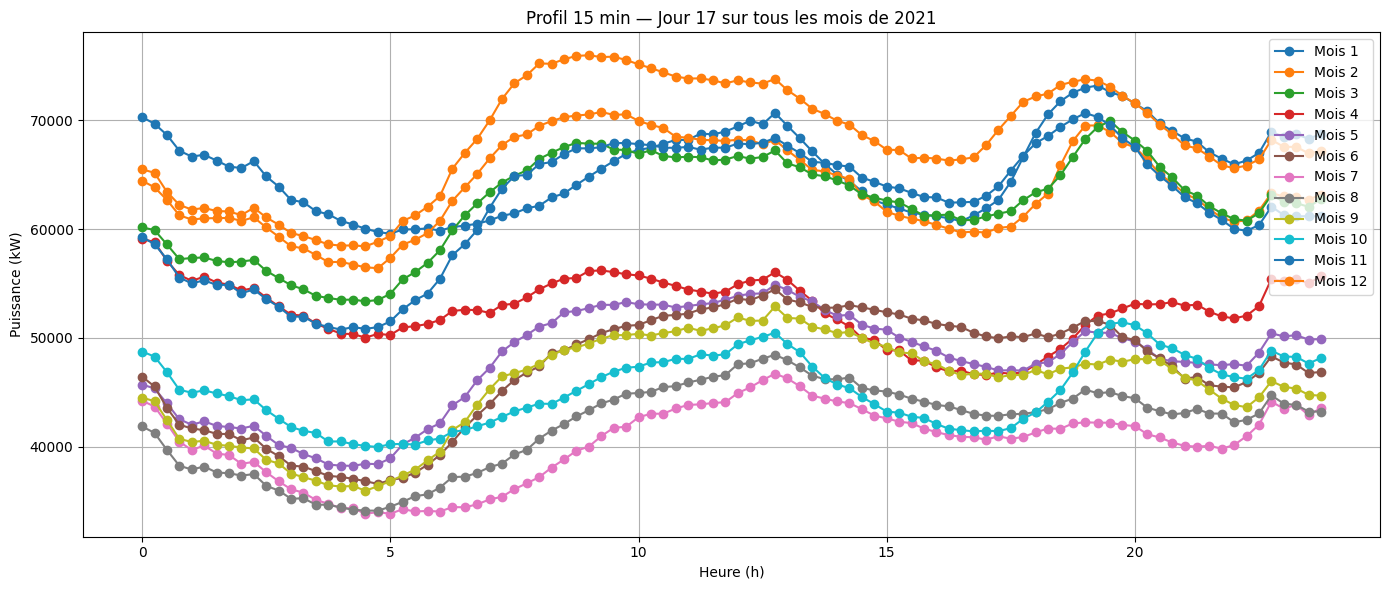

In [12]:
#Puissance moyenne sur toutes les 15 min

df = data_power.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

selected_year = 2021
selected_day = 17

df_filtered = df[
    (df["year"] == selected_year) &
    (df["day"] == selected_day)
].copy()

plt.figure(figsize=(14, 6))

for month in sorted(df_filtered["month"].unique()):
    df_month = df_filtered[df_filtered["month"] == month].sort_values("timestamp")

    # Convert time to fractional hours to avoid the "datetime.time" error
    x = (
        df_month["timestamp"].dt.hour
        + df_month["timestamp"].dt.minute / 60
        + df_month["timestamp"].dt.second / 3600
    )

    plt.plot(
        x,
        df_month["Consommation"],
        marker='o',
        linestyle='-',
        label=f"Mois {month}"
    )

plt.title(f"Profil 15 min — Jour {selected_day} sur tous les mois de {selected_year}")
plt.xlabel("Heure (h)")
plt.ylabel("Puissance (kW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
